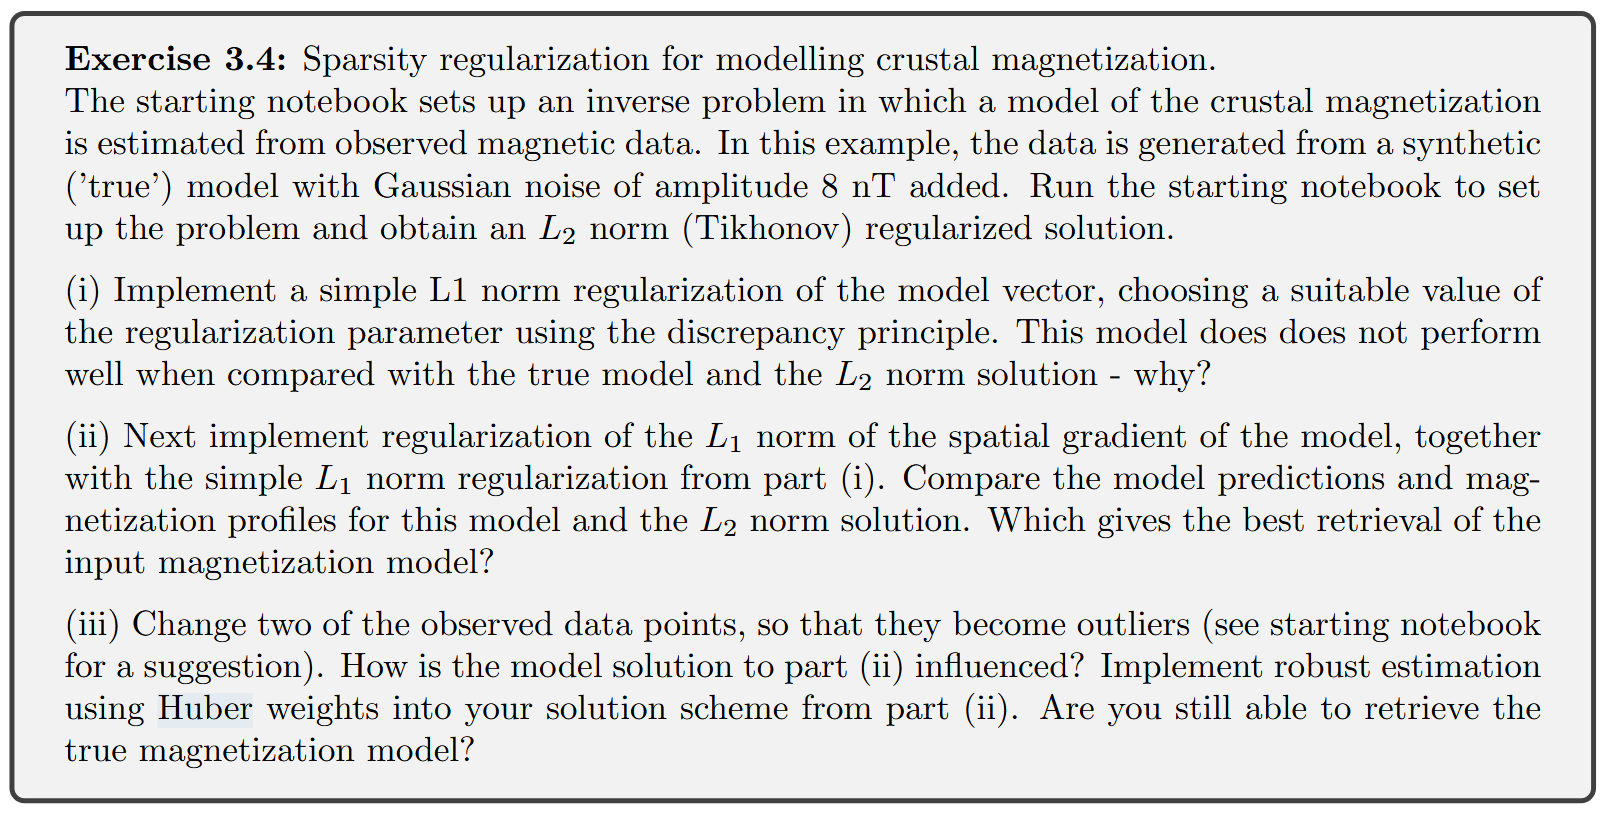

In [39]:
# Inverse modelling of magnetic anomaly over a mid-ocean ridge
# Using L1 norm, total variation, robust estimation and IRLS

# For DTU MSc course Inverse Problems and Machine Learning in Earth and Space Physics

# Starting script setting up problem, and synthetic data

In [40]:
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
import polars as pl
import seaborn as sns
from tqdm.auto import tqdm, trange

In [41]:
def G_crust(x_j, x_m, h):
    # Regarding constant pre-factor [not crucial for understanding]
    # -\mu_0/2pi = -2 x10-^7
    # But Magnetization in SI Am^-1, data in nT=10^-9 T
    # So finally correct prefactor is -200 [See Parker, 1994 for details]

    x_m = x_m.reshape(1, -1)
    x_j = x_j.reshape(-1, 1)
    g = -200 * ((x_m - x_j) ** 2 - h**2) / ((x_m - x_j) ** 2 + h**2) ** 2

    return g

In [42]:
# Set up 1D grid for locations of model magnetization
delta_x_m = 0.1
x_m = np.arange(-25, 25 + delta_x_m, delta_x_m)

# define data locations
x_j = np.arange(-15, 15 + 1, 1)

# Build design matrix
h = 2  # Depth of water (km)
G = G_crust(x_j, x_m, h) * delta_x_m

In [43]:
# Define synthetic model
m = np.zeros((len(x_m), 1))
ones = np.ones((51, 1))

m[np.arange(250 - 127, 251 - 77)] = 2 * ones
m[np.arange(250 - 76, 251 - 26)] = -2 * ones
m[np.arange(250 - 25, 251 + 25)] = 2 * ones
m[np.arange(250 + 26, 251 + 76)] = -2 * ones
m[np.arange(250 + 77, 251 + 127)] = 2 * ones

m_true = m.copy()

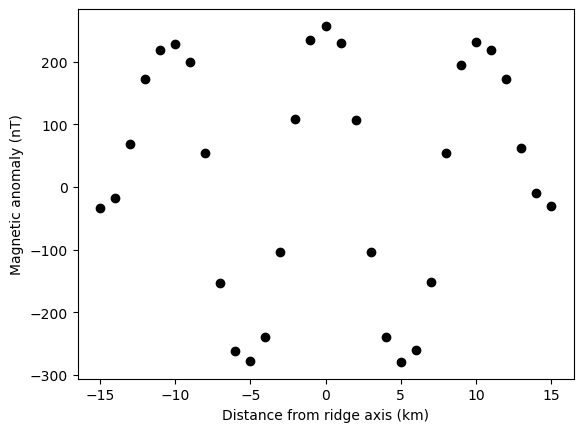

In [44]:
# Produce synthetic data
d_j = G @ m

# Add Gaussian noise of amplitude 8 nT
dn_j = 8 * np.random.rand(len(d_j), 1)  # NOTE! This is WRONG (uniform, [0, 1])
# dn_j = 8 * np.random.normal(size=d_j.shape)
d_j = d_j + dn_j

# Add Outliers
# d_j[12]=300
# d_j[20]=d_j[19]

# Plot data
plt.figure()
plt.plot(x_j, d_j, "ko")
plt.xlabel("Distance from ridge axis (km)")
plt.ylabel("Magnetic anomaly (nT)")
plt.show()

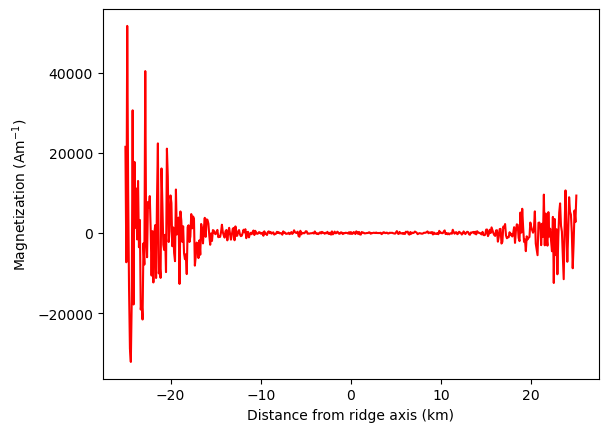

rms misfit: 9.547643092277516e-12


In [45]:
# Simple least squares soln.
m_ls = np.linalg.solve(
    (G.T @ G), G.T @ d_j
)  # Direct least sq inversion: v. poor result

# Plot simple least squares soln
plt.figure()
plt.plot(x_m, m_ls, "-r")
plt.xlabel("Distance from ridge axis (km)")
plt.ylabel(r"Magnetization (Am$^{-1}$)")
plt.show()

# Residuals
r_ls = d_j - G @ m_ls
# rms misfit
rms_resid_ls = np.sqrt(r_ls.T @ r_ls / len(d_j))
print("rms misfit:", rms_resid_ls[0, 0])

rms misfit: 7.693064814146696


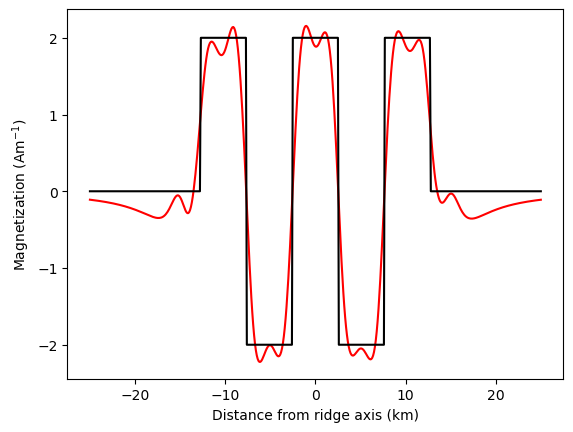

In [46]:
# L2 norm Tikhonov Regularized solution

alpha_sq = 3.95e1  # For discrepancy principle
GTG = G.T @ G

# Determine Tikhonov solution
I = np.identity(len(GTG))
m_L2tik = np.linalg.solve((GTG + alpha_sq * I), G.T @ d_j)

# Residuals
r_L2tik = d_j - G @ m_L2tik
# rms misfit
rms_resid_L2tik = np.sqrt(r_L2tik.T @ r_L2tik / len(d_j))
print("rms misfit:", rms_resid_L2tik[0, 0])

## Plot regularized solution: much more reasonable
plt.figure()
plt.plot(x_m, m_L2tik, "-r")
plt.plot(x_m, m_true, "k")
plt.xlabel("Distance from ridge axis (km)")
plt.ylabel(r"Magnetization (Am$^{-1}$)")
plt.show()

## 3.4.i

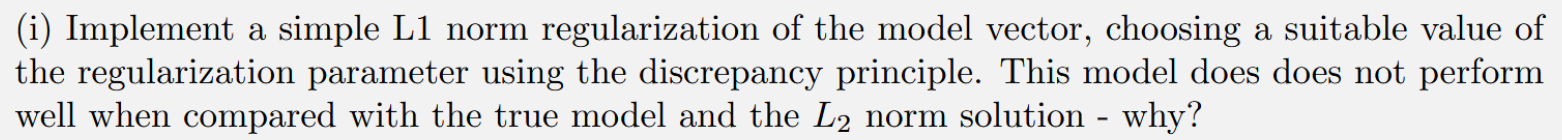

In [48]:
# From p. 21, eq. (47)

# Initialise
alpha_L1 = 0.1
N = len(GTG)
H = np.identity(N)
m = np.zeros((N,))
gamma = np.ones((N,))

iter_data = []
for i in range(250):
    W_m = np.diag(1 / np.abs(gamma))
    m_new = np.linalg.solve(G.T @ G + (alpha_L1**2) * H.T @ W_m @ H, G.T @ d_j)[:, 0]

    m_diff = m - m_new
    m_diff_L2 = np.linalg.norm(m_diff)

    m = m_new
    gamma = H @ m

    iter_data.append(
        {
            "i": i,
            "m_diff_L2": m_diff_L2,
        }
    )

    if np.isnan(m_diff_L2) or m_diff_L2 < 1e-6:
        print("Convergence reached at iteration", i)
        break

df = pl.DataFrame(iter_data)


Convergence reached at iteration 177


C:\Users\jeppe\AppData\Local\Temp\ipykernel_53660\3655537822.py:12: RuntimeWarning: overflow encountered in divide
  W_m = np.diag(1 / np.abs(gamma))


  0%|          | 0/500 [00:00<?, ?it/s]

Text(0.5, 1.0, 'L1 regularization')

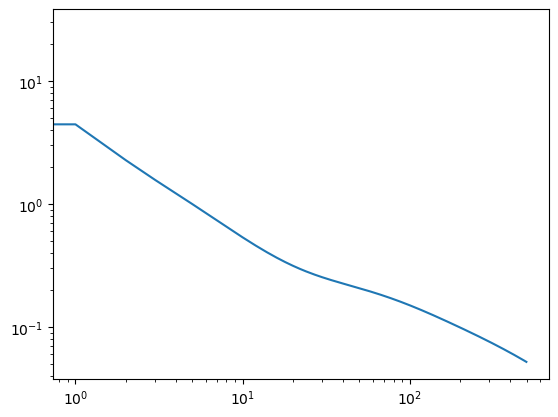

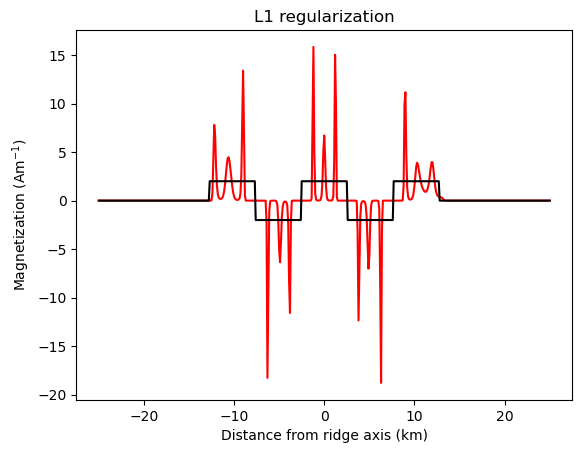

In [65]:
def irls_lp(
    G, H, d, alpha, delta, p, N_iter: int = 1000, diff_threshold: float = 1e-6
) -> tuple[npt.NDArray, list[dict[str, Any]]]:
    GTG = G.T @ G
    N = len(GTG)
    K = H.shape[0]

    d_vec = d.reshape(-1)

    m_L1 = np.zeros((N,))
    gamma = np.ones((K,))

    iter_data = []
    for i in trange(N_iter):
        ekblom = (gamma**2 + delta**2) ** (p / 2 - 1)
        W_m = np.diag(ekblom)

        m_L1_new = np.linalg.solve(G.T @ G + (alpha**2) * H.T @ W_m @ H, G.T @ d_vec)

        m_diff = m_L1 - m_L1_new
        m_diff_L2 = np.linalg.norm(m_diff)

        if np.isnan(m_diff_L2) or m_diff_L2 / N < diff_threshold:
            break

        m_L1 = m_L1_new
        gamma = H @ m_L1

        iter_data.append(
            {
                "i": i,
                "m_diff_L2": m_diff_L2,
            }
        )

    return m_L1, iter_data


N = len(GTG)
H = np.identity(N)
alpha_L1 = np.sqrt(5.8e1)
delta_L1 = np.sqrt(1e-8)

m, iter_data = irls_lp(G, H, d_j, alpha_L1, delta_L1, p=1, N_iter=500)

df = pl.DataFrame(iter_data)
plt.figure()
plt.plot(df["i"], df["m_diff_L2"])
plt.loglog()

plt.figure()
plt.plot(x_m, m, "-r")
plt.plot(x_m, m_true, "k")
plt.xlabel("Distance from ridge axis (km)")
plt.ylabel(r"Magnetization (Am$^{-1}$)")
plt.title("L1 regularization")

Commentary: Model performs okay, but really struggles to capture the high-frequency edges.

This may be improved by punalising the derivative (first difference, Total Variation regularisation)

## 3.4.ii

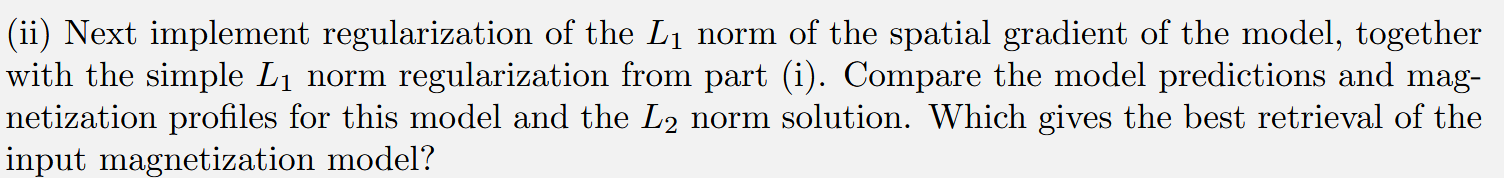

'H_diff: '

array([[-1.,  1.,  0., ...,  0.,  0.,  0.],
       [ 0., -1.,  1., ...,  0.,  0.,  0.],
       [ 0.,  0., -1., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  0.,  0., ...,  1.,  0.,  0.],
       [ 0.,  0.,  0., ..., -1.,  1.,  0.],
       [ 0.,  0.,  0., ...,  0., -1.,  1.]], shape=(500, 501))

  0%|          | 0/1000 [00:00<?, ?it/s]

Text(0.5, 1.0, 'L1 regularization')

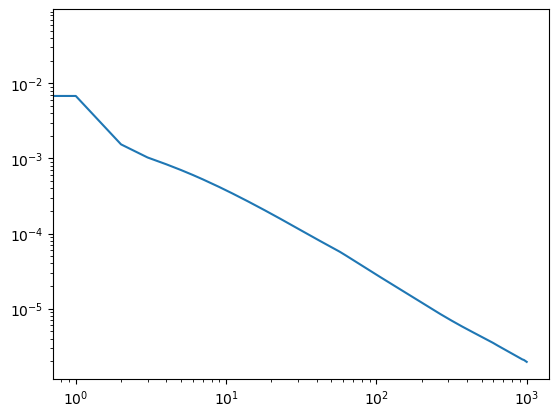

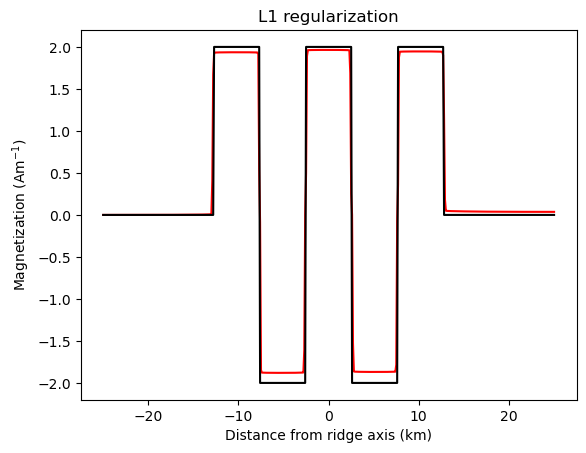

In [71]:
def irls_lp_multi(
    G,
    Hs,
    d,
    alphas,
    deltas,
    p,
    N_iter: int = 1000,
    diff_threshold: float = 1e-6,
    verbose: bool = False,
) -> tuple[npt.NDArray, list[dict[str, Any]]]:
    GTG = G.T @ G
    N = len(GTG)

    d_vec = d.reshape(-1)
    m_L1 = np.zeros((N,))
    gammas = [np.ones((H.shape[0],)) for H in Hs]

    iter_data = []

    if verbose:
        iter_ = trange(N_iter)
    else:
        iter_ = range(N_iter)

    for i in iter_:
        reg_term = np.zeros_like(GTG)
        for gamma, alpha, delta, H in zip(gammas, alphas, deltas, Hs):
            ekblom = (gamma**2 + delta**2) ** (p / 2 - 1)
            W_m = np.diag(ekblom)
            reg_term += (alpha**2) * H.T @ W_m @ H

        m_L1_new = np.linalg.solve(GTG + reg_term, G.T @ d_vec)

        m_diff = m_L1 - m_L1_new
        m_diff_L2 = np.linalg.norm(m_diff)

        if np.isnan(m_diff_L2) or m_diff_L2 / N < diff_threshold:
            break

        m_L1 = m_L1_new

        for j, H in enumerate(Hs):
            gammas[j] = H @ m_L1

        iter_data.append(
            {
                "i": i,
                "m_diff_L2": m_diff_L2 / N,
            }
        )

    return m_L1, iter_data


N = len(GTG)
H_identity = np.identity(N)
H_diff = np.diff(np.eye(N), axis=0)  # shape: (N-1, N)
display("H_diff: ", H_diff)

alpha_L1 = np.sqrt(7)
delta_L1 = np.sqrt(1e-8)
alpha_L1_diff = np.sqrt(2e3)
delta_L1_diff = np.sqrt(1e-8)

Hs = [H_identity, H_diff]
alphas = [alpha_L1, alpha_L1_diff]
deltas = [delta_L1, delta_L1_diff]


m_out, iter_data = irls_lp_multi(
    G, Hs, d_j, alphas, deltas, p=1, N_iter=1000, diff_threshold=1e-6, verbose=True
)
df = pl.DataFrame(iter_data)
plt.figure()
plt.plot(df["i"], df["m_diff_L2"])
plt.loglog()

plt.figure()
plt.plot(x_m, m_out, "-r")
plt.plot(x_m, m_true, "k")
plt.xlabel("Distance from ridge axis (km)")
plt.ylabel(r"Magnetization (Am$^{-1}$)")
plt.title("L1 regularization")

Commenary:


In [51]:
# Step 1: Only do spatial gradient
N = len(GTG)
H_identity = np.identity(N)
H_diff = np.diff(np.eye(N), axis=0)  # shape: (N-1, N)
display("H_diff: ", H_diff)

dp_data = []
for alpha_L1_diff_sq in tqdm(np.geomspace(1, 1e3, 20)):
    alpha_L1 = np.sqrt(0)
    delta_L1 = np.sqrt(1e-8)
    alpha_L1_diff = np.sqrt(alpha_L1_diff_sq)
    delta_L1_diff = np.sqrt(1e-8)

    Hs = [H_identity, H_diff]
    alphas = [alpha_L1, alpha_L1_diff]
    deltas = [delta_L1, delta_L1_diff]

    m, iter_data = irls_lp_multi(
        G, Hs, d_j, alphas, deltas, p=1, N_iter=100, diff_threshold=1e-6, verbose=False
    )

    residual = d_j[:, 0] - G @ m

    dp_data.append(
        {
            "m_L1": m,
            "alpha_L1": alpha_L1,
            "alpha_L1_diff": alpha_L1_diff,
            "residual_L2": np.linalg.norm(residual),
            "rmse": np.sqrt(residual.T @ residual / len(d_j)),
        }
    )

'H_diff: '

array([[-1.,  1.,  0., ...,  0.,  0.,  0.],
       [ 0., -1.,  1., ...,  0.,  0.,  0.],
       [ 0.,  0., -1., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  0.,  0., ...,  1.,  0.,  0.],
       [ 0.,  0.,  0., ..., -1.,  1.,  0.],
       [ 0.,  0.,  0., ...,  0., -1.,  1.]], shape=(500, 501))

  0%|          | 0/20 [00:00<?, ?it/s]

DP alpha_L1_diff: 31.622776601683793


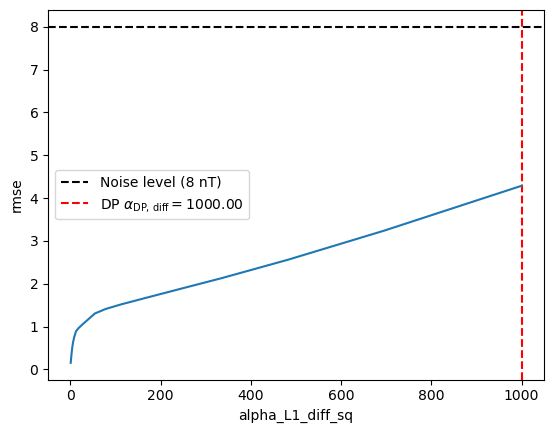

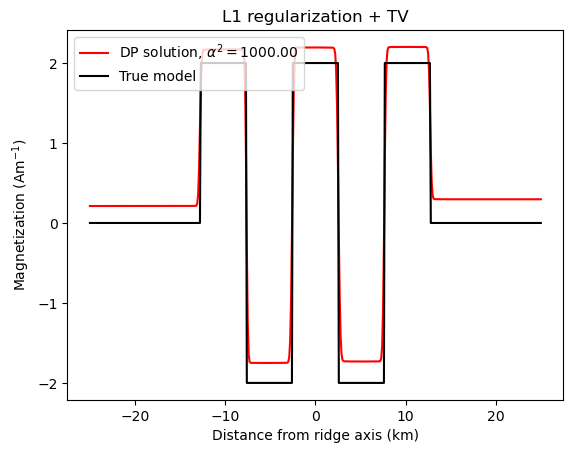

In [52]:
df = pl.DataFrame(dp_data)
df = df.with_columns((pl.col("alpha_L1") ** 2).alias("alpha_L1_sq"))
df = df.with_columns((pl.col("alpha_L1_diff") ** 2).alias("alpha_L1_diff_sq"))

# Know noise is ≈ 8nT here
dp_criterion = 8.0

closest_row = (
    df.with_columns(
        (pl.col("rmse") - dp_criterion).abs().alias("dp_dist")
    )
    .sort("dp_dist")
    .head(1)
)
alpha_L1_diff_dp = closest_row["alpha_L1_diff"][0]
alpha_L1_diff_sq_dp = closest_row["alpha_L1_diff_sq"][0]
m_dp = closest_row["m_L1"][0]

plt.axhline(8, color="k", linestyle="--", label="Noise level (8 nT)")
plt.axvline(alpha_L1_diff_sq_dp, color="r", linestyle="--", label=f"DP $α_{{\\text{{DP, diff}}}}={alpha_L1_diff_sq_dp:.2f}$")
sns.lineplot(df, x="alpha_L1_diff_sq", y="rmse")

print("DP alpha_L1_diff:", alpha_L1_diff_dp)

plt.figure()
plt.plot(x_m, m_dp, "-r", label=f"DP solution, $α^2={alpha_L1_diff_sq_dp:.2f}$")
plt.plot(x_m, m_true, "k", label="True model")
plt.xlabel("Distance from ridge axis (km)")
plt.ylabel(r"Magnetization (Am$^{-1}$)")
plt.title("L1 regularization + TV")
plt.legend(loc= "upper left")

Commentary: 
- Pretty good agreement, appears to be biased to be too high. This makes sense, since null space of derivative is addition of a constant!

In [72]:
# Step 2: Optimise with both active
N = len(GTG)
H_identity = np.identity(N)
H_diff = np.diff(np.eye(N), axis=0)  # shape: (N-1, N)
display("H_diff: ", H_diff)

dp_data = []
for alpha_L1_sq in tqdm(np.geomspace(1e-4, 10, 20)):
    alpha_L1 = np.sqrt(alpha_L1_sq)
    delta_L1 = np.sqrt(1e-8)
    alpha_L1_diff = np.sqrt(alpha_L1_diff_sq_dp)
    delta_L1_diff = np.sqrt(1e-8)

    Hs = [H_identity, H_diff]
    alphas = [alpha_L1, alpha_L1_diff]
    deltas = [delta_L1, delta_L1_diff]

    m, iter_data = irls_lp_multi(
        G, Hs, d_j, alphas, deltas, p=1, N_iter=500, diff_threshold=1e-6, verbose=False
    )

    residual = d_j[:, 0] - G @ m

    dp_data.append(
        {
            "m_L1": m,
            "alpha_L1": alpha_L1,
            "alpha_L1_diff": alpha_L1_diff,
            "residual_L2": np.linalg.norm(residual),
            "rmse": np.sqrt(residual.T @ residual / len(d_j)),
        }
    )

df_2_step2 = pl.DataFrame(dp_data)


'H_diff: '

array([[-1.,  1.,  0., ...,  0.,  0.,  0.],
       [ 0., -1.,  1., ...,  0.,  0.,  0.],
       [ 0.,  0., -1., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  0.,  0., ...,  1.,  0.,  0.],
       [ 0.,  0.,  0., ..., -1.,  1.,  0.],
       [ 0.,  0.,  0., ...,  0., -1.,  1.]], shape=(500, 501))

  0%|          | 0/20 [00:00<?, ?it/s]

KeyboardInterrupt: 

DP alpha_L1_sq: 10.000000000000002


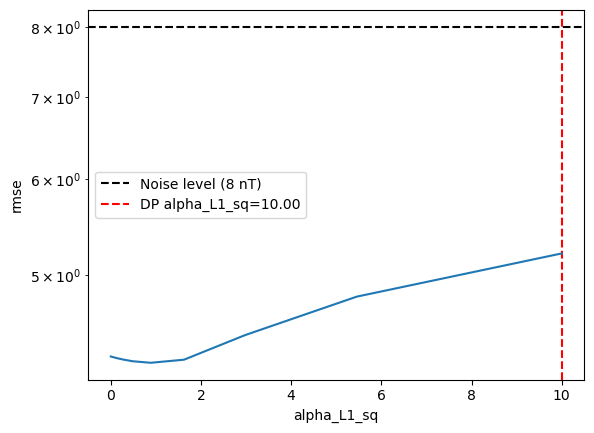

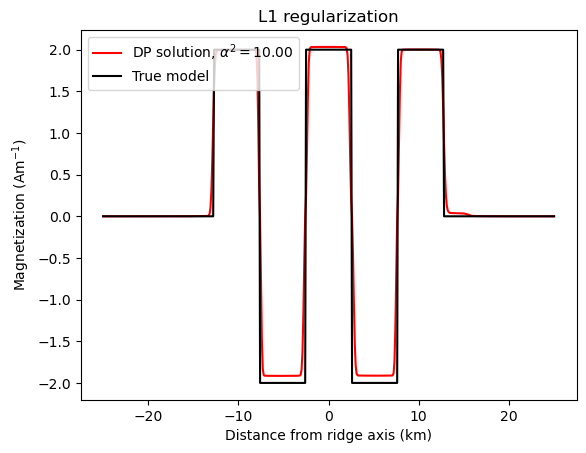

In [ ]:
df = pl.DataFrame(dp_data)
df = df.with_columns((pl.col("alpha_L1") ** 2).alias("alpha_L1_sq"))
df = df.with_columns((pl.col("alpha_L1_diff") ** 2).alias("alpha_L1_diff_sq"))

# Know noise is ≈ 8nT here
dp_criterion = 8.0

closest_row = (
    df.with_columns(
        (pl.col("rmse") - dp_criterion).abs().alias("dp_dist")
    )
    .sort("dp_dist")
    .head(1)
)
alpha_L1_dp = closest_row["alpha_L1"][0]
alpha_L1_sq_dp = closest_row["alpha_L1_sq"][0]
m_dp = closest_row["m_L1"][0]

plt.axhline(8, color="k", linestyle="--", label="Noise level (8 nT)")
plt.axvline(alpha_L1_sq_dp, color="r", linestyle="--", label=f"DP alpha_L1_sq={alpha_L1_sq_dp:.2f}")
sns.lineplot(df, x="alpha_L1_sq", y="rmse")
plt.semilogy()

print("DP alpha_L1_sq:", alpha_L1_sq_dp)

plt.figure()
plt.plot(x_m, m_dp, "-r", label=f"DP solution, $α^2={alpha_L1_sq_dp:.2f}$")
plt.plot(x_m, m_true, "k", label="True model")
plt.xlabel("Distance from ridge axis (km)")
plt.ylabel(r"Magnetization (Am$^{-1}$)")
plt.title("L1 regularization")
plt.legend(loc= "upper left")

  0%|          | 0/100 [00:00<?, ?it/s]

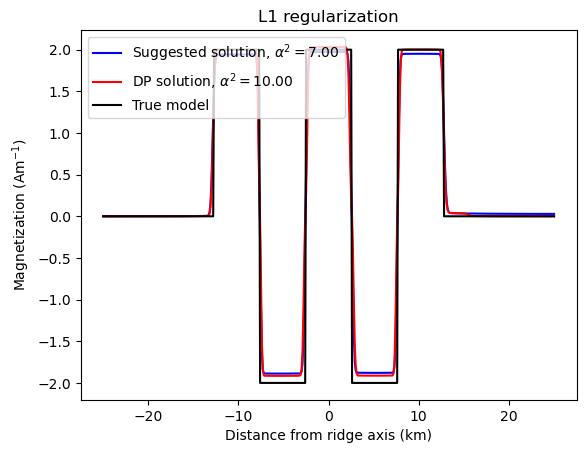

In [ ]:
# Try their suggestion
alpha_L1 = np.sqrt(7)
delta_L1 = np.sqrt(1e-8)
alpha_L1_diff = np.sqrt(2e3)
delta_L1_diff = np.sqrt(1e-8)

Hs = [H_identity, H_diff]
alphas = [alpha_L1, alpha_L1_diff]
deltas = [delta_L1, delta_L1_diff]

m_suggest, iter_data = irls_lp_multi(
    G, Hs, d_j, alphas, deltas, p=1, N_iter=100, diff_threshold=1e-6, verbose=True
)

plt.figure()
plt.plot(x_m, m_suggest, "-b", label=f"Suggested solution, $α^2={alpha_L1**2:.2f}$")
plt.plot(x_m, m_dp, "-r", label=f"DP solution, $α^2={alpha_L1_sq_dp:.2f}$")
plt.plot(x_m, m_true, "k", label="True model")
plt.xlabel("Distance from ridge axis (km)")
plt.ylabel(r"Magnetization (Am$^{-1}$)")
plt.title("L1 regularization")
plt.legend(loc= "upper left")

## 3.4.iii

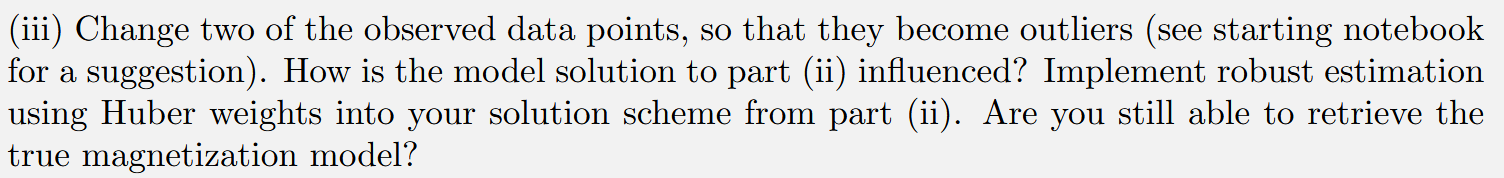

In [73]:
def huber_weights(residuals, c):
    return np.minimum(c / np.abs(residuals), np.ones_like(residuals))

sigma = 8.0

def irls_lp_multi_robust(
    G,
    Hs,
    d,
    alphas,
    deltas,
    p,
    c: float = 1.5,  # Huber cutoff
    N_iter: int = 1000,
    diff_threshold: float = 1e-6,
    verbose: bool = False,
) -> tuple[npt.NDArray, list[dict[str, Any]]]:
    N = G.shape[1]
    M = G.shape[0]

    d_vec = d.reshape(-1)
    assert d_vec.shape == (M,)

    m = np.zeros((N,))
    gammas = [np.ones((H.shape[0],)) for H in Hs]
    W_r = np.eye(M)  # Robust weights

    iter_data = []

    if verbose:
        iter_ = trange(N_iter)
    else:
        iter_ = range(N_iter)

    for i in iter_:
        reg_term = np.zeros((N, N))
        for gamma, alpha, delta, H in zip(gammas, alphas, deltas, Hs):
            ekblom = (gamma**2 + delta**2) ** (p / 2 - 1)
            W_m = np.diag(ekblom)
            reg_term += (alpha**2) * H.T @ W_m @ H

        GTWG = G.T @ W_r @ G

        m_new = np.linalg.solve(GTWG + reg_term, G.T @ W_r @ d_vec)


        m_diff = m - m_new
        m_diff_L2 = np.linalg.norm(m_diff)

        if np.isnan(m_diff_L2) or m_diff_L2 / N < diff_threshold:
            break

        m = m_new

        residuals = d_vec - G @ m
        W_r = np.diag(huber_weights(residuals/sigma, c=c))
        for j, H in enumerate(Hs):
            gammas[j] = H @ m

        iter_data.append(
            {
                "i": i,
                "m_diff_L2": m_diff_L2 / N,
            }
        )

    return m, iter_data



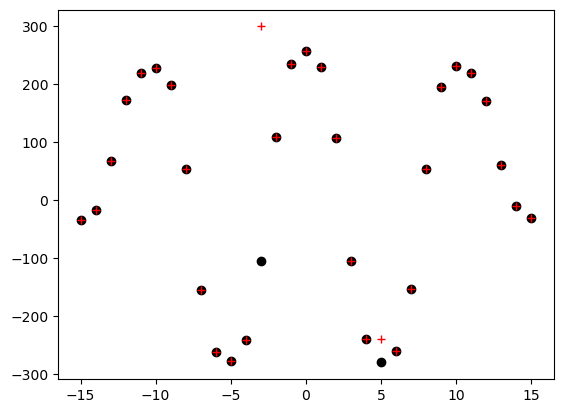

In [74]:
d_j_outliers = d_j.copy()
d_j_outliers[12] = 300
d_j_outliers[20] = d_j_outliers[19]

plt.plot(x_j, d_j, "ko")
plt.plot(x_j, d_j_outliers, "r+")

In [75]:
# Try solve with Huber weights
N = len(GTG)
H_identity = np.identity(N)
H_diff = np.diff(np.eye(N), axis=0)  # shape: (N-1, N)

alpha_L1 = np.sqrt(3)
delta_L1 = np.sqrt(1e-3)
alpha_L1_diff = np.sqrt(3e2)
delta_L1_diff = np.sqrt(1e-8)

Hs = [H_identity, H_diff]
alphas = [alpha_L1, alpha_L1_diff]
deltas = [delta_L1, delta_L1_diff]

m_not_robust, iter_data = irls_lp_multi(
    G, Hs, d_j_outliers, alphas, deltas, p=1, N_iter=250, diff_threshold=1e-6, verbose=True
)
m_robust, iter_data = irls_lp_multi_robust(
    G, Hs, d_j_outliers, alphas, deltas, p=1, N_iter=250, diff_threshold=1e-6, verbose=True
)


  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

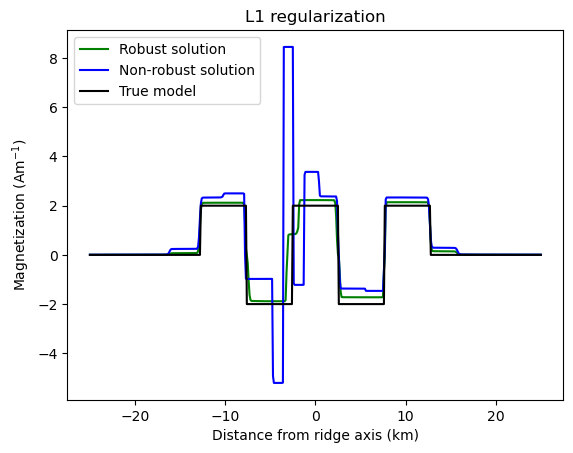

In [76]:
plt.figure()
# plt.plot(x_m, m_suggest, "-b", label=f"Suggested solution, $α^2={alpha_L1**2:.2f}$")
# plt.plot(x_m, m_dp, "-r", label=f"DP solution, $α^2={alpha_L1_sq_dp:.2f}$")
plt.plot(x_m, m_robust, "-g", label="Robust solution")
plt.plot(x_m, m_not_robust, "-b", label="Non-robust solution")
plt.plot(x_m, m_true, "k", label="True model")
plt.xlabel("Distance from ridge axis (km)")
plt.ylabel(r"Magnetization (Am$^{-1}$)")
plt.title("L1 regularization")
plt.legend(loc= "upper left")

Comments:
- Model without robust weights blows up a bit
- Reweighted model with suggested alphas does not seem to be correct.

NOTES TO SELF:
- Remember to scale ε in Huber weights by σ
- Remember to weight residuals by robust weights (not done here), i.e. RMSE = sqrt((R.T @ W @ R) / N)